이 자료는 위키독스 '딥 러닝을 이용한 자연어 처리 입문'의 트랜스포머 튜토리얼로 작성되었습니다.  

챗봇의 성능이 아쉽다면 모델의 크기를 조정해보세요.

링크 :  
https://wikidocs.net/31379  
https://wikidocs.net/89786

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
tf.__version__

'2.19.0'

단어 임베딩 + 위치 임베딩
→ 모델이 “단어 의미 + 순서 정보”를 동시에 알 수 있게 됨.

In [50]:
class PositionalEncoding(tf.keras.layers.Layer):
  def __init__(self, position, d_model, **kwargs):
    super(PositionalEncoding, self).__init__(**kwargs)
    self.position = position
    self.d_model = d_model
    # 위치 인코딩을 미리 한 번 계산해 두고 상수로 저장
    self.pos_encoding = self.positional_encoding(position, d_model)

  def get_angles(self, position, i, d_model):
    # 논문 공식: angle = pos / (10000^(2i/d_model))
    angles = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
    return position * angles

  def positional_encoding(self, position, d_model):
    # position: (position, 1), i: (1, d_model)
    positions = tf.range(position, dtype=tf.float32)[:, tf.newaxis]
    dims = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]

    angle_rads = self.get_angles(positions, dims, d_model)  # (position, d_model)

    # 짝수 인덱스: sin, 홀수 인덱스: cos
    sines = tf.math.sin(angle_rads[:, 0::2])
    cosines = tf.math.cos(angle_rads[:, 1::2])

    # sin, cos를 다시 interleave 해서 (position, d_model) 만들기
    # 짝/홀 위치를 채우기 위해 0으로 초기화 후 scatter
    angle_rads_sin_cos = tf.TensorArray(tf.float32, size=d_model)

    # 짝수 차원 채우기
    even_indices = tf.range(0, d_model, 2)
    odd_indices = tf.range(1, d_model, 2)

    # sin, cos를 합쳐 하나의 텐서로 구성
    # 간단히 zeros_like 를 쓰고 assign 하는 방식으로 처리
    pos_encoding = tf.zeros_like(angle_rads)
    pos_encoding = tf.tensor_scatter_nd_update(
        pos_encoding,
        tf.stack([tf.repeat(tf.range(position), d_model // 2),
                  tf.tile(even_indices, [position // 1])], axis=1),
        tf.reshape(sines, [-1])
    )
    pos_encoding = tf.tensor_scatter_nd_update(
        pos_encoding,
        tf.stack([tf.repeat(tf.range(position), d_model // 2),
                  tf.tile(odd_indices, [position // 1])], axis=1),
        tf.reshape(cosines, [-1])
    )

    # 배치 차원을 앞에 하나 추가 → (1, position, d_model)
    pos_encoding = pos_encoding[tf.newaxis, ...]
    return tf.cast(pos_encoding, tf.float32)

  def call(self, inputs):
    # ✅ SparseTensor로 들어오는 경우를 안전하게 처리
    if isinstance(inputs, tf.SparseTensor):
      inputs = tf.sparse.to_dense(inputs)

    seq_len = tf.shape(inputs)[1]
    # 입력 시퀀스 길이에 해당하는 만큼만 잘라서 더해줌
    return inputs + self.pos_encoding[:, :seq_len, :]

  def compute_output_shape(self, input_shape):
    # 위치 인코딩은 입력과 동일한 shape을 유지
    return input_shape

1. 가로축(Depth)

   - 임베딩의 각 차원(0~127)을 의미

   - 짝수 차원은 sin, 홀수 차원은 cos 패턴

   - 차원이 증가할수록 파장의 길이가 달라짐 → 더 길고 느린/짧고 빠른 파형

2. 세로축(Position)

   - 문장 내 단어의 위치 (0~49)

3. 색상(Red–Blue gradient)

   - 해당 위치·차원에서의 Positional Encoding 값

   - 빨강 = 양수, 파랑 = 음수

   - sin/cos 패턴이 섞여 나타남

In [18]:
!rm -rf ~/.cache/matplotlib

In [35]:
!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 설치된 나눔글꼴 경로 확인
font_paths = !fc-list :lang=ko
for p in font_paths:
    print(p)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf: NanumBarunGothic,나눔바른고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothic.ttf: NanumGothic,나눔고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf: NanumGothicCoding,나눔고딕코딩:style=Regular
/usr/share/fonts/truetype/nanum/NanumBarun

In [36]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# fc-list에서 확인한 정확한 경로 적기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# FontProperties 생성
fontprop = fm.FontProperties(fname=font_path)

# minus 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# ------ 여기서 중요한 부분 ------
# rc로 family 이름을 지정하는 게 아니라
# rcParams['font.family'] 에 직접 경로 기반 이름을 넣는 방식
plt.rcParams['font.family'] = fontprop.get_name()
print("사용되는 폰트 이름:", fontprop.get_name())


사용되는 폰트 이름: NanumGothic


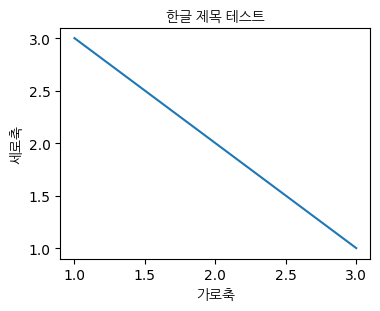

In [37]:
plt.figure(figsize=(4,3))
plt.title("한글 제목 테스트", fontproperties=fontprop)
plt.xlabel("가로축", fontproperties=fontprop)
plt.ylabel("세로축", fontproperties=fontprop)
plt.plot([1,2,3],[3,2,1])
plt.show()


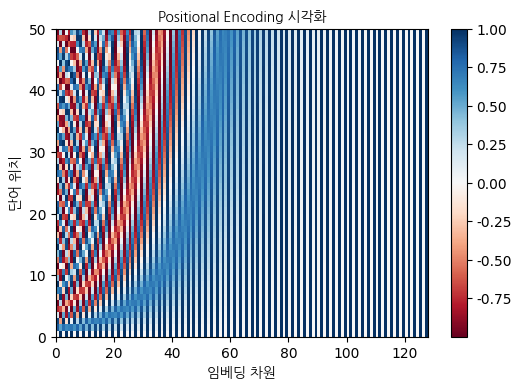

In [51]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(sample_pos_encoding.pos_encoding.numpy()[0], cmap='RdBu')
plt.xlabel('임베딩 차원', fontproperties=fontprop)
plt.ylabel('단어 위치', fontproperties=fontprop)
plt.title('Positional Encoding 시각화', fontproperties=fontprop)
plt.colorbar()
plt.show()


| 단계                | 의미                | 결과               |
| ----------------- | ----------------- | ---------------- |
| **1. Q·Kᵀ**       | 단어들 간 연관성 계산      | Score Matrix     |
| **2. /√d**        | 값의 크기 조정          | 안정된 분포           |
| **3. Mask**       | 패딩/미래 단어 제거       | 불필요한 정보 0 처리     |
| **4. Softmax**    | 각 위치의 중요도를 확률로 변환 | Attention Weight |
| **5. Weight × V** | 중요한 정보만 출력으로 반영   | Attention Output |


In [52]:
def scaled_dot_product_attention(query, key, value, mask):
  # query: (batch, heads, query_length, depth)
  # key:   (batch, heads, key_length, depth)
  # value: (batch, heads, value_length, depth)
  # mask:  (batch, 1, 1, key_length)  → 가려야 하는 위치를 1로 표시

  # 1) Q · K^T 내적
  #    → 단어들 사이의 유사도 계산
  #    → "어떤 단어가 어떤 단어에 얼마나 집중해야 하는가?" 점수 생성
  matmul_qk = tf.matmul(query, key, transpose_b=True)

  # 2) 스케일링
  #    depth = key 벡터의 차원 수
  #    값이 너무 커지는 것을 방지하기 위해 √depth 로 나눔
  #    → 값의 크기를 안정화시켜 softmax가 잘 작동하도록 함
  depth = tf.cast(tf.shape(key)[-1], tf.float32)
  logits = matmul_qk / tf.math.sqrt(depth)

  # 3) 마스킹(mask)
  #    미래 단어 또는 패딩(pad) 부분을 가리고 싶을 때 사용
  #    mask 부분에 -1e9 같은 매우 작은 값을 더하면
  #    softmax에서 거의 0으로 만들어 ‘무시’하게 됨
  if mask is not None:
    logits += (mask * -1e9)

  # 4) 소프트맥스(softmax)
  #    마지막 차원(key_length) 기준으로 확률값 변환
  #    → Attention Weight 생성
  #    (각 query 단어가 key 문장의 어떤 위치에 집중하는지 확률로 표현)
  attention_weights = tf.nn.softmax(logits, axis=-1)

  # 5) Attention weights × Value
  #    → 최종으로 집중해야 할 정보를 뽑아낸 결과 output
  #    (각 단어에 대해 중요한 정보만 모아 재구성)
  output = tf.matmul(attention_weights, value)

  # output: (batch, heads, query_length, depth)
  # attention_weights: (batch, heads, query_length, key_length)
  return output, attention_weights

### 왜 “Multi-Head”인가?

- 한 종류의 Attention만 계산하면 “하나의 관점”만 반영됨

- 여러 개(head)의 Attention을 병렬로 수행하면
- → 의미, 위치, 문법, 유사성 등 다양한 관계를 동시에 학습 가능

| 목적            | 설명                                 |
| ------------- | ---------------------------------- |
| **다양한 관점 반영** | 의미, 문법, 위치 등 여러 관계를 동시에 학습         |
| **학습 안정성 향상** | 각 head가 작은 depth를 처리해 계산 효율 증가     |
| **표현력 증가**    | 여러 head에서 수집한 정보를 종합하여 더 풍부한 표현 생성 |


| 단계                                  | 수행 내용                                | 결과/목적                         |
| ----------------------------------- | ------------------------------------ | ----------------------------- |
| **1. q, k, v 생성**                   | 입력에 WQ, WK, WV(Dense layer) 적용       | 단어 벡터를 “질문·특징·정보” 형태로 변환      |
| **2. Head 분리**                      | d_model → num_heads로 나누어 depth 계산    | 여러 관점에서 Attention 계산 가능       |
| **3. Scaled Dot-Product Attention** | 각 head마다 Q·Kᵀ, /√d, mask, softmax 수행 | 단어 간 중요도(Attention weight) 계산 |
| **4. Head 연결(Concatenate)**         | 모든 head 출력 합쳐 하나의 벡터로 복원             | 다양한 관점에서 얻은 정보를 통합            |
| **5. W_O 통과(Dense)**                | 최종 linear 변환                         | 원래 d_model 차원으로 조정된 최종 출력     |


In [53]:
class MultiHeadAttention(tf.keras.layers.Layer):

  def __init__(self, d_model, num_heads, name="multi_head_attention"):
    super(MultiHeadAttention, self).__init__(name=name)

    self.num_heads = num_heads     # 어텐션을 몇 개의 “머리”로 나눌지
    self.d_model = d_model         # 임베딩 전체 차원 수

    # d_model이 head 개수로 정확히 나누어져야 각 head의 차원이 동일하게 됨
    assert d_model % self.num_heads == 0

    # 하나의 head가 처리할 차원 수
    # (논문 기준 64 = 512(d_model)/8(heads))
    self.depth = d_model // self.num_heads

    # W_Q, W_K, W_V : q, k, v를 만들기 위한 선형 변환(Dense)
    self.query_dense = tf.keras.layers.Dense(units=d_model)
    self.key_dense   = tf.keras.layers.Dense(units=d_model)
    self.value_dense = tf.keras.layers.Dense(units=d_model)

    # W_O : 여러 head를 합친 후 최종적으로 다시 d_model로 변환해주는 Dense
    self.dense = tf.keras.layers.Dense(units=d_model)


  # ---------------------------------------------
  # 여러 head로 나누는 함수
  # inputs: (batch, seq_len, d_model)
  # output: (batch, num_heads, seq_len, depth)
  # ---------------------------------------------
  def split_heads(self, inputs, batch_size):
    # (batch, seq, d_model) → (batch, seq, heads, depth)
    inputs = tf.reshape(inputs, shape=(batch_size, -1, self.num_heads, self.depth))

    # 차원을 바꿔 head가 앞쪽으로 오도록 재배열
    # → (batch, heads, seq, depth)
    return tf.transpose(inputs, perm=[0, 2, 1, 3])


  def call(self, inputs):
    # 입력 딕셔너리에서 q, k, v, mask 추출
    query, key, value, mask = (
        inputs['query'], inputs['key'], inputs['value'], inputs['mask']
    )

    batch_size = tf.shape(query)[0]

    # ------------------------------------------------------------
    # 1. W_Q, W_K, W_V를 통과시켜 q, k, v 생성
    # ------------------------------------------------------------
    # 각각 (batch, seq_len, d_model)
    query = self.query_dense(query)
    key   = self.key_dense(key)
    value = self.value_dense(value)

    # ------------------------------------------------------------
    # 2. 여러 head로 나누기
    # ------------------------------------------------------------
    # (batch, heads, seq_len, depth)
    query = self.split_heads(query, batch_size)
    key   = self.split_heads(key, batch_size)
    value = self.split_heads(value, batch_size)

    # ------------------------------------------------------------
    # 3. 각 head마다 scaled dot-product attention 수행
    # ------------------------------------------------------------
    # scaled_attention: (batch, heads, query_len, depth)
    scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

    # 원래 순서로 되돌림
    # (batch, query_len, heads, depth)
    scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])

    # ------------------------------------------------------------
    # 4. 모든 head를 다시 하나로 연결(concatenate)
    # ------------------------------------------------------------
    # (batch, query_len, d_model)
    concat_attention = tf.reshape(scaled_attention,
                                  (batch_size, -1, self.d_model))

    # ------------------------------------------------------------
    # 5. W_O(linear) 통과 → Multi-Head Attention 최종 출력
    # ------------------------------------------------------------
    outputs = self.dense(concat_attention)

    return outputs

Padding Mask는 pad 토큰(0)을 softmax에서 ‘0% 집중’으로 만들어
모델이 패딩을 계산에 사용하지 않도록 완전히 제거하는 역할을 한다.

| 단계                    | 설명                               | 결과                           |
| --------------------- | -------------------------------- | ---------------------------- |
| **1. pad 위치 찾기**      | `tf.math.equal(x, 0)`            | pad 토큰이면 True                |
| **2. float으로 변환**     | `tf.cast(..., float32)`          | pad → 1, 나머지 → 0             |
| **3. 차원 확장**          | `[:, tf.newaxis, tf.newaxis, :]` | (batch, 1, 1, seq_len) 형태 완성 |
| **4. Attention에서 사용** | mask * -1e9                      | softmax에서 pad 부분 확률 0        |


In [54]:
def create_padding_mask(x):
  # x: (batch_size, seq_len)
  #    → 입력 문장에서 pad 토큰(0)이 있는 위치를 찾기 위한 입력

  # x에서 값이 0인 위치(True)를 float형으로 변환 → pad 자리: 1, 나머지: 0
  mask = tf.cast(tf.math.equal(x, 0), tf.float32)

  # 마스크 모양을 Attention에 맞게 확장
  # (batch, 1, 1, seq_len)
  # → 모든 head가 동일하게 pad 위치를 가릴 수 있도록 차원 확장
  return mask[:, tf.newaxis, tf.newaxis, :]

Encoder Layer는
(1) Self-Attention → (2) FFN
두 서브층으로 구성되고,
각 서브층은 Dropout + Residual Connection + Layer Normalization을 포함한다.

| 단계                         | 구성 요소                     | 입력 → 출력                   | 설명                 |
| -------------------------- | ------------------------- | ------------------------- | ------------------ |
| **① Self-Attention**       | Multi-Head Attention      | inputs → attention        | 단어들 간 관계 파악(Q=K=V) |
| **② Residual + LayerNorm** | inputs + attention → 정규화  | 안정적인 학습, 정보 보존            |                    |
| **③ Feed-Forward Network** | 두 개의 Dense                | attention → FFN → ffn_out | 비선형 변환을 통한 표현 확장   |
| **④ Residual + LayerNorm** | attention + ffn_out → 정규화 | 깊은 층에서도 정보 유지             |                    |


In [55]:
def encoder_layer(dff, d_model, num_heads, dropout, name="encoder_layer"):

  # 인코더 입력: (batch, seq_len, d_model)
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")

  # 인코더에서 사용하는 패딩 마스크: (batch, 1, 1, seq_len)
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # -----------------------------------------------------
  # 1) Self-Attention 서브층
  # -----------------------------------------------------

  # Q = K = V = inputs (Self-Attention)
  attention = MultiHeadAttention(
      d_model, num_heads, name="attention")({
          'query': inputs,
          'key': inputs,
          'value': inputs,
          'mask': padding_mask
      })

  # dropout 적용
  attention = tf.keras.layers.Dropout(rate=dropout)(attention)

  # Residual Connection + Layer Normalization
  # 입력 + 어텐션 결과 → 정규화
  attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

  # -----------------------------------------------------
  # 2) Feed-Forward Network(FFN) 서브층
  # -----------------------------------------------------

  # 첫 Dense: dff 크기의 은닉층 + ReLU 비선형 활성화
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention)

  # 두 번째 Dense: 차원을 다시 d_model로 복구
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # dropout 적용
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)

  # Residual Connection + Layer Normalization
  # attention + FFN 결과 → 정규화
  outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention + outputs)

  # 최종 Encoder Layer 모델 반환
  return tf.keras.Model(
      inputs=[inputs, padding_mask],
      outputs=outputs,
      name=name)

Encoder =
“임베딩 + 위치 정보”를 더한 뒤,
Self-Attention + FFN으로 이루어진 Encoder Layer를 num_layers번 쌓아서
각 단어의 문맥적 표현을 만들어 내는 모듈”

### Encoder 입력/출력

| 항목             | 형태                        | 설명                            |
| -------------- | ------------------------- | ----------------------------- |
| `inputs`       | (batch, seq_len)          | 정수 토큰 ID 시퀀스                  |
| `padding_mask` | (batch, 1, 1, seq_len)    | PAD 토큰 가리기 위한 마스크             |
| `outputs`      | (batch, seq_len, d_model) | 마지막 인코더 블록의 표현(문맥을 반영한 토큰 벡터) |


In [56]:
def encoder(vocab_size, num_layers, dff,
            d_model, num_heads, dropout,
            name="encoder"):
  # 입력 토큰 시퀀스: (batch, seq_len)
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 인코더에서 사용할 패딩 마스크: (batch, 1, 1, seq_len)
  padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

  # -------------------------------------------------
  # 1. 임베딩 + 포지셔널 인코딩 + 드롭아웃
  # -------------------------------------------------

  # 단어 ID → 임베딩 벡터 (batch, seq_len, d_model)
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)

  # 논문처럼 임베딩 값을 √d_model로 스케일링
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))

  # 위치 정보(포지셔널 인코딩) 추가
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)

  # 드롭아웃으로 과적합 방지
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # -------------------------------------------------
  # 2. 인코더 레이어를 num_layers개 쌓기
  # -------------------------------------------------
  for i in range(num_layers):
    outputs = encoder_layer(
        dff=dff,
        d_model=d_model,
        num_heads=num_heads,
        dropout=dropout,
        name="encoder_layer_{}".format(i),
    )([outputs, padding_mask])

  # -------------------------------------------------
  # 3. 전체 Encoder 모델 반환
  # -------------------------------------------------
  # inputs: 토큰 시퀀스, padding_mask
  # outputs: 마지막 인코더 레이어 출력 (batch, seq_len, d_model)
  return tf.keras.Model(
      inputs=[inputs, padding_mask],
      outputs=outputs,
      name=name)

- Look-Ahead Mask = “디코더가 미래 단어를 보지 못하게 막는 삼각 마스크”
- 여기에 Padding Mask까지 합쳐
- "미래 단어" + "PAD" 둘 다 완전히 가리게 된다.

| Mask 종류             | 역할         | 예시                                      |
| ------------------- | ---------- | --------------------------------------- |
| **Look-Ahead Mask** | 미래 토큰 가리기  | “나는 사과를 먹었다”에서 1번 단어는 2·3·4번 단어를 보면 안 됨 |
| **Padding Mask**    | PAD 토큰 가리기 | `<pad>`가 어텐션 계산에 포함되지 않도록 제거            |


In [57]:
# 디코더의 첫 번째 서브층에서 "미래 토큰을 보지 못하게" 만드는 마스크 생성
def create_look_ahead_mask(x):
  # x: (batch, seq_len)  — 토큰 ID 시퀀스
  seq_len = tf.shape(x)[1]

  # ------------------------------
  # 1) Look-Ahead Mask (미래 가리기)
  # ------------------------------
  # band_part에서 아래 삼각행렬(포함)을 남기므로
  # 1 - 아래삼각행렬 → 자기 자신 이후 미래 위치는 1, 과거는 0
  #
  # 예) seq_len=4
  # [[0 1 1 1]
  #  [0 0 1 1]
  #  [0 0 0 1]
  #  [0 0 0 0]]
  look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

  # ------------------------------
  # 2) Padding Mask (PAD 가리기)
  # ------------------------------
  padding_mask = create_padding_mask(x)   # (batch, 1, 1, seq_len)

  # ------------------------------
  # 3) look-ahead + paddingMask 합치기
  # ------------------------------
  # 둘 중 하나라도 1이면 mask 적용 (최대값 선택)
  # shape broadcasting을 통해 디코더에서 사용할 (batch, seq_len, seq_len) 형태로 확장됨
  return tf.maximum(look_ahead_mask, padding_mask)

In [58]:
def decoder_layer(dff, d_model, num_heads, dropout, name="decoder_layer"):
  inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
  enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")

  # 디코더는 룩어헤드 마스크(첫번째 서브층)와 패딩 마스크(두번째 서브층) 둘 다 사용.
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name="look_ahead_mask")
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 멀티-헤드 어텐션 (첫번째 서브층 / 마스크드 셀프 어텐션)
  attention1 = MultiHeadAttention(
      d_model, num_heads, name="attention_1")(inputs={
          'query': inputs, 'key': inputs, 'value': inputs, # Q = K = V
          'mask': look_ahead_mask # 룩어헤드 마스크
      })

  # 잔차 연결과 층 정규화
  attention1 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention1 + inputs)

  # 멀티-헤드 어텐션 (두번째 서브층 / 디코더-인코더 어텐션)
  attention2 = MultiHeadAttention(
      d_model, num_heads, name="attention_2")(inputs={
          'query': attention1, 'key': enc_outputs, 'value': enc_outputs, # Q != K = V
          'mask': padding_mask # 패딩 마스크
      })

  # 드롭아웃 + 잔차 연결과 층 정규화
  attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
  attention2 = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(attention2 + attention1)

  # 포지션 와이즈 피드 포워드 신경망 (세번째 서브층)
  outputs = tf.keras.layers.Dense(units=dff, activation='relu')(attention2)
  outputs = tf.keras.layers.Dense(units=d_model)(outputs)

  # 드롭아웃 + 잔차 연결과 층 정규화
  outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
  outputs = tf.keras.layers.LayerNormalization(
      epsilon=1e-6)(outputs + attention2)

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)

In [59]:
def decoder(vocab_size, num_layers, dff,
            d_model, num_heads, dropout,
            name='decoder'):
  inputs = tf.keras.Input(shape=(None,), name='inputs')
  enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')

  # 디코더는 룩어헤드 마스크(첫번째 서브층)와 패딩 마스크(두번째 서브층) 둘 다 사용.
  look_ahead_mask = tf.keras.Input(
      shape=(1, None, None), name='look_ahead_mask')
  padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

  # 포지셔널 인코딩 + 드롭아웃
  embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
  embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
  embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
  outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

  # 디코더를 num_layers개 쌓기
  for i in range(num_layers):
    outputs = decoder_layer(dff=dff, d_model=d_model, num_heads=num_heads,
        dropout=dropout, name='decoder_layer_{}'.format(i),
    )(inputs=[outputs, enc_outputs, look_ahead_mask, padding_mask])

  return tf.keras.Model(
      inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask],
      outputs=outputs,
      name=name)

In [60]:
def transformer(vocab_size, num_layers, dff,
                d_model, num_heads, dropout,
                name="transformer"):

  # 인코더의 입력
  inputs = tf.keras.Input(shape=(None,), name="inputs")

  # 디코더의 입력
  dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs")

  # 인코더의 패딩 마스크
  enc_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='enc_padding_mask')(inputs)

  # 디코더의 룩어헤드 마스크(첫번째 서브층)
  look_ahead_mask = tf.keras.layers.Lambda(
      create_look_ahead_mask, output_shape=(1, None, None),
      name='look_ahead_mask')(dec_inputs)

  # 디코더의 패딩 마스크(두번째 서브층)
  dec_padding_mask = tf.keras.layers.Lambda(
      create_padding_mask, output_shape=(1, 1, None),
      name='dec_padding_mask')(inputs)

  # 인코더의 출력은 enc_outputs. 디코더로 전달된다.
  enc_outputs = encoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
      d_model=d_model, num_heads=num_heads, dropout=dropout,
  )(inputs=[inputs, enc_padding_mask]) # 인코더의 입력은 입력 문장과 패딩 마스크

  # 디코더의 출력은 dec_outputs. 출력층으로 전달된다.
  dec_outputs = decoder(vocab_size=vocab_size, num_layers=num_layers, dff=dff,
      d_model=d_model, num_heads=num_heads, dropout=dropout,
  )(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

  # 다음 단어 예측을 위한 출력층
  outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

  return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)

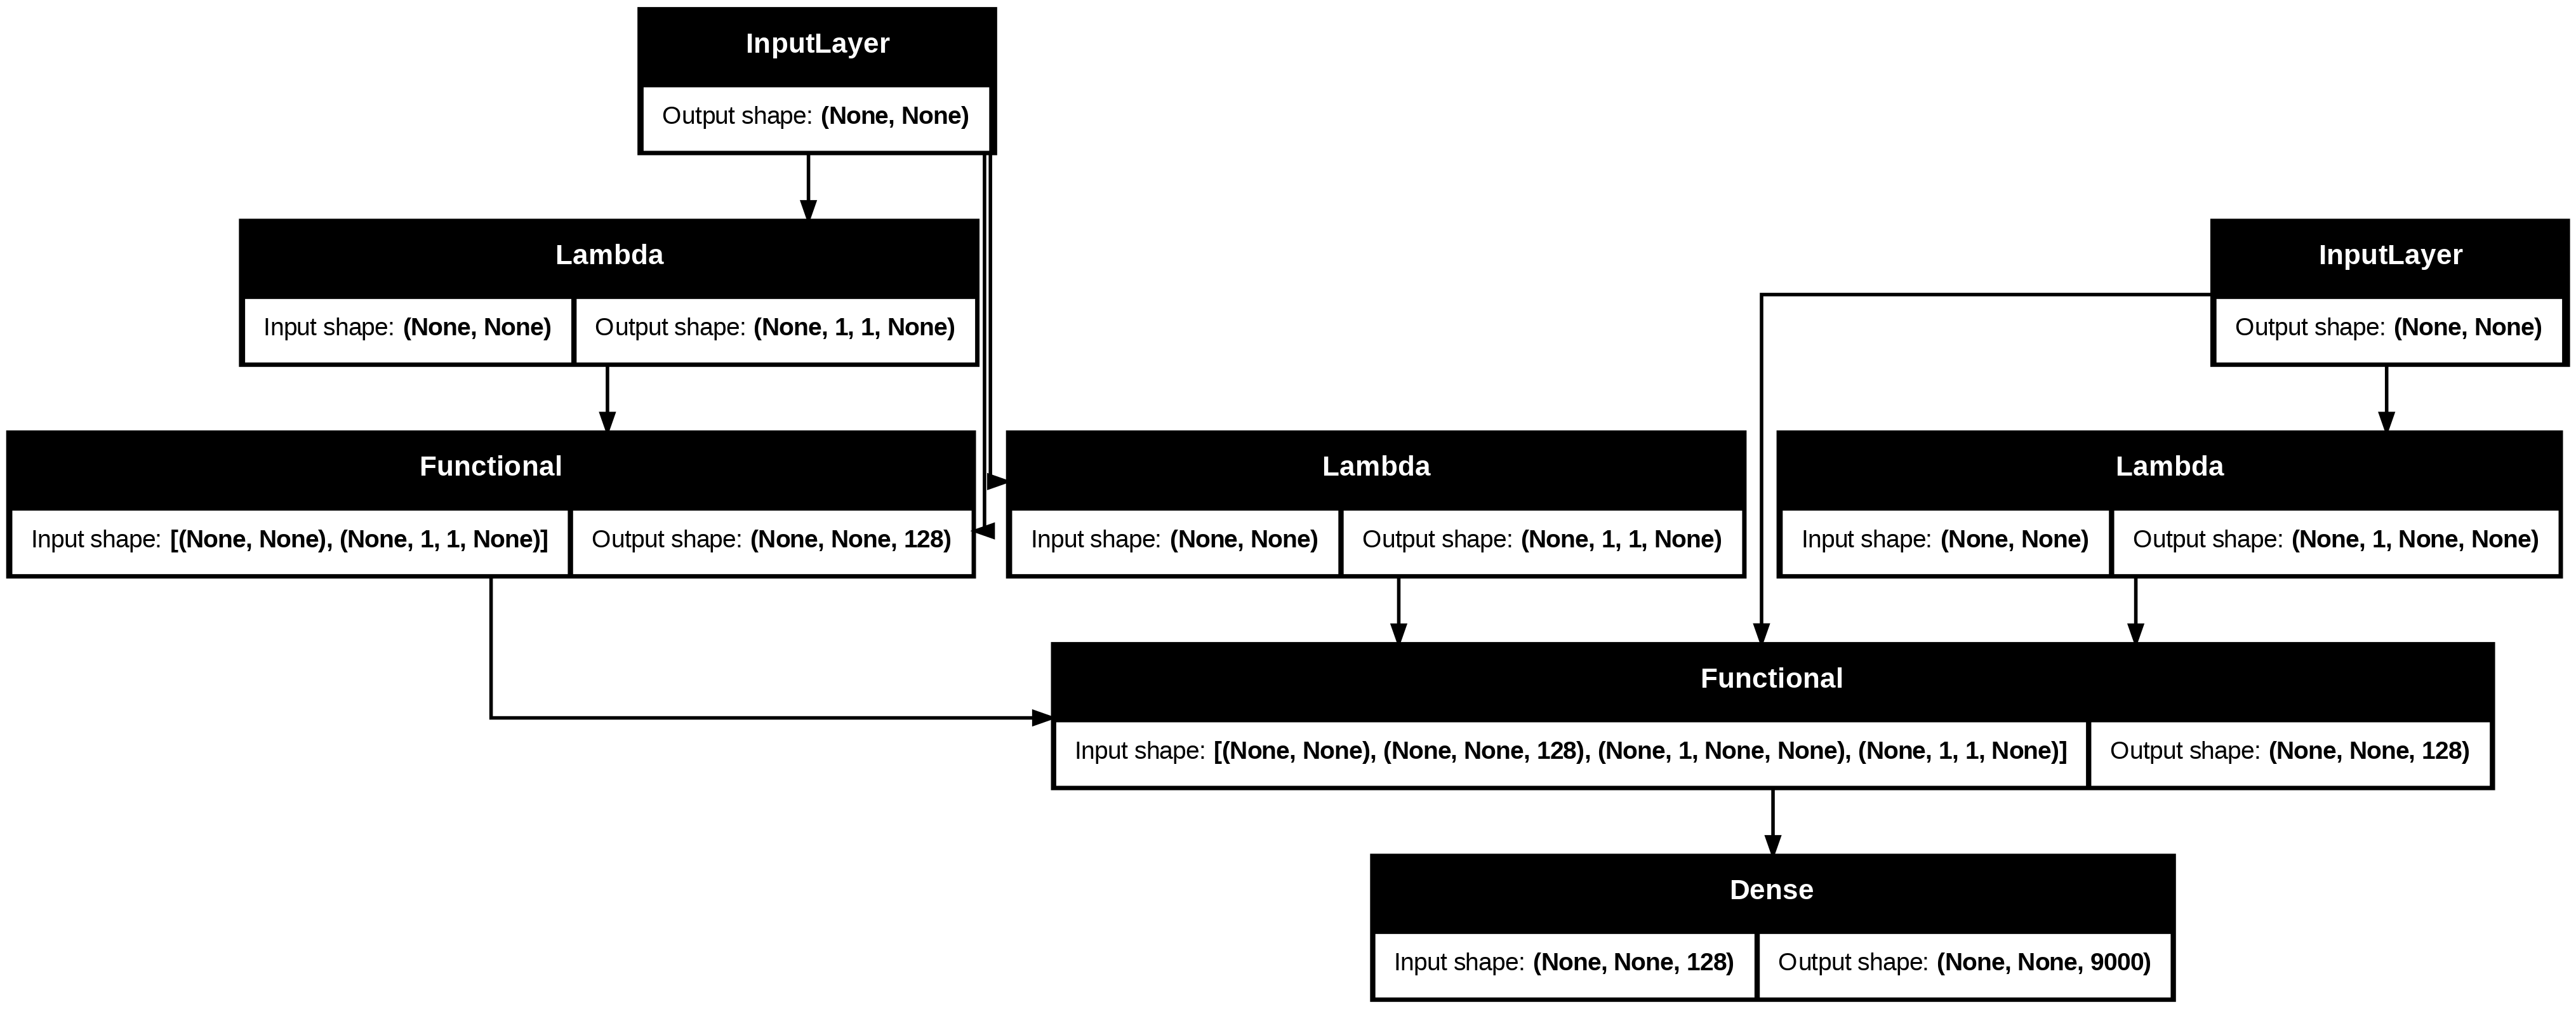

In [61]:
small_transformer = transformer(
    vocab_size = 9000,
    num_layers = 4,
    dff = 512,
    d_model = 128,
    num_heads = 8,
    dropout = 0.1,
    name="small_transformer"
)

tf.keras.utils.plot_model(
    small_transformer, to_file='small_transformer.png', show_shapes=True)

In [62]:
def loss_function(y_true, y_pred):
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))

  loss = tf.keras.losses.SparseCategoricalCrossentropy(
      from_logits=True, reduction='none')(y_true, y_pred)

  mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
  loss = tf.multiply(loss, mask)

  return tf.reduce_mean(loss)

In [63]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):

  def __init__(self, d_model, warmup_steps=4000):
    super(CustomSchedule, self).__init__()
    self.d_model = tf.cast(d_model, tf.float32)
    self.warmup_steps = warmup_steps

  def __call__(self, step):
    # 논문에서 사용한 learning rate 스케줄 공식
    # lr = d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))
    arg1 = tf.math.rsqrt(step)
    arg2 = step * (self.warmup_steps ** -1.5)

    return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

Text(0.5, 0, 'Train Step')

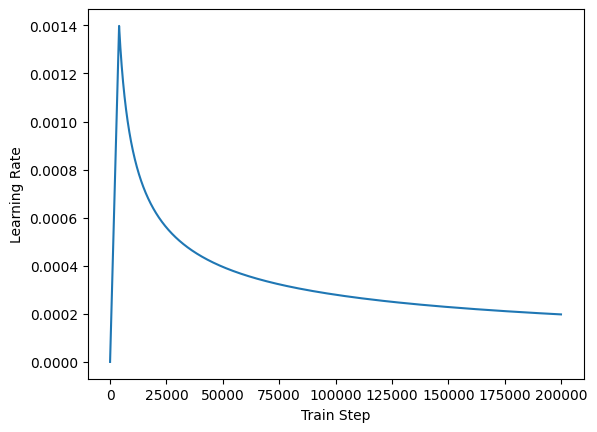

In [64]:
sample_learning_rate = CustomSchedule(d_model=128)

plt.plot(sample_learning_rate(tf.range(200000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")

# 챗봇 구현

In [65]:
import pandas as pd
import urllib.request
import tensorflow_datasets as tfds
import tensorflow as tf
import time
import numpy as np
import matplotlib.pyplot as plt
import re

In [66]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv", filename="ChatBotData.csv")

train_data = pd.read_csv('ChatBotData.csv')
train_data.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [67]:
print('챗봇 샘플의 개수 :', len(train_data))

챗봇 샘플의 개수 : 11823


In [68]:
print(train_data.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [69]:
questions = []
for sentence in train_data['Q']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    questions.append(sentence)

In [70]:
answers = []
for sentence in train_data['A']:
    # 구두점에 대해서 띄어쓰기
    # ex) 12시 땡! -> 12시 땡 !
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = sentence.strip()
    answers.append(sentence)

In [71]:
len(questions)

11823

In [72]:
print(questions[:5])
print(answers[:5])

['12시 땡 !', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네']
['하루가 또 가네요 .', '위로해 드립니다 .', '여행은 언제나 좋죠 .', '여행은 언제나 좋죠 .', '눈살이 찌푸려지죠 .']


In [73]:
# 서브워드텍스트인코더를 사용하여 질문과 답변을 모두 포함한 단어 집합(Vocabulary) 생성
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    questions + answers, target_vocab_size=2**13)

# 시작 토큰과 종료 토큰에 대한 정수 부여.
START_TOKEN, END_TOKEN = [tokenizer.vocab_size], [tokenizer.vocab_size + 1]

# 시작 토큰과 종료 토큰을 고려하여 단어 집합의 크기를 + 2
VOCAB_SIZE = tokenizer.vocab_size + 2

In [74]:
print('시작 토큰 번호 :',START_TOKEN)
print('종료 토큰 번호 :',END_TOKEN)
print('단어 집합의 크기 :',VOCAB_SIZE)

시작 토큰 번호 : [8178]
종료 토큰 번호 : [8179]
단어 집합의 크기 : 8180


In [75]:
# 서브워드텍스트인코더 토크나이저의 .encode()를 사용하여 텍스트 시퀀스를 정수 시퀀스로 변환.
print('Tokenized sample question: {}'.format(tokenizer.encode(questions[20])))

Tokenized sample question: [5766, 611, 3509, 141, 685, 3747, 849]


In [76]:
# 서브워드텍스트인코더 토크나이저의 .encode()와 decode() 테스트해보기

# 임의의 입력 문장을 sample_string에 저장
sample_string = questions[20]

# encode() : 텍스트 시퀀스 --> 정수 시퀀스
tokenized_string = tokenizer.encode(sample_string)
print ('정수 인코딩 후의 문장 {}'.format(tokenized_string))

# decode() : 정수 시퀀스 --> 텍스트 시퀀스
original_string = tokenizer.decode(tokenized_string)
print ('기존 문장: {}'.format(original_string))

정수 인코딩 후의 문장 [5766, 611, 3509, 141, 685, 3747, 849]
기존 문장: 가스비 비싼데 감기 걸리겠어


In [77]:
# 각 정수는 각 단어와 어떻게 mapping되는지 병렬로 출력
# 서브워드텍스트인코더는 의미있는 단위의 서브워드로 토크나이징한다. 띄어쓰기 단위 X 형태소 분석 단위 X
for ts in tokenized_string:
  print ('{} ----> {}'.format(ts, tokenizer.decode([ts])))

5766 ----> 가스
611 ----> 비 
3509 ----> 비싼
141 ----> 데 
685 ----> 감기 
3747 ----> 걸리
849 ----> 겠어


In [78]:
# 최대 길이를 40으로 정의
MAX_LENGTH = 40

# 토큰화 / 정수 인코딩 / 시작 토큰과 종료 토큰 추가 / 패딩
def tokenize_and_filter(inputs, outputs):
  tokenized_inputs, tokenized_outputs = [], []

  for (sentence1, sentence2) in zip(inputs, outputs):
    # encode(토큰화 + 정수 인코딩), 시작 토큰과 종료 토큰 추가
    sentence1 = START_TOKEN + tokenizer.encode(sentence1) + END_TOKEN
    sentence2 = START_TOKEN + tokenizer.encode(sentence2) + END_TOKEN

    tokenized_inputs.append(sentence1)
    tokenized_outputs.append(sentence2)

  # 패딩
  tokenized_inputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_inputs, maxlen=MAX_LENGTH, padding='post')
  tokenized_outputs = tf.keras.preprocessing.sequence.pad_sequences(
      tokenized_outputs, maxlen=MAX_LENGTH, padding='post')

  return tokenized_inputs, tokenized_outputs

In [79]:
questions, answers = tokenize_and_filter(questions, answers)

In [80]:
print('질문 데이터의 크기(shape) :', questions.shape)
print('답변 데이터의 크기(shape) :', answers.shape)

질문 데이터의 크기(shape) : (11823, 40)
답변 데이터의 크기(shape) : (11823, 40)


In [81]:
# 0번째 샘플을 임의로 출력
print(questions[0])
print(answers[0])

[8178 7915 4207 3060   41 8179    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
[8178 3844   74 7894    1 8179    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


In [82]:
print('단어 집합의 크기(Vocab size): {}'.format(VOCAB_SIZE))
print('전체 샘플의 수(Number of samples): {}'.format(len(questions)))

단어 집합의 크기(Vocab size): 8180
전체 샘플의 수(Number of samples): 11823


In [88]:
# 텐서플로우 dataset을 이용하여 셔플(shuffle)을 수행하되, 배치 크기로 데이터를 묶는다.
# 또한 이 과정에서 교사 강요(teacher forcing)을 사용하기 위해서 디코더의 입력과 실제값 시퀀스를 구성한다.
BATCH_SIZE = 64
BUFFER_SIZE = 20000

# 디코더의 실제값 시퀀스에서는 시작 토큰을 제거해야 한다.
dataset = tf.data.Dataset.from_tensor_slices((
    {
        'inputs': questions,
        'dec_inputs': answers[:, :-1]  # 디코더 입력 (시작~끝-1)
    },
    answers[:, 1:]                      # 디코더 타깃 (시작+1~끝)
))

dataset = dataset.cache()
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)

In [89]:
# 임의의 샘플에 대해서 [:, :-1]과 [:, 1:]이 어떤 의미를 가지는지 테스트해본다.
print(answers[0]) # 기존 샘플
print(answers[:1][:, :-1]) # 마지막 패딩 토큰 제거하면서 길이가 39가 된다.
print(answers[:1][:, 1:]) # 맨 처음 토큰이 제거된다. 다시 말해 시작 토큰이 제거된다. 길이는 역시 39가 된다.

[8178 3844   74 7894    1 8179    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]
[[8178 3844   74 7894    1 8179    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]]
[[3844   74 7894    1 8179    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]]


In [90]:
tf.keras.backend.clear_session()

# Hyper-parameters
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
DFF = 512
DROPOUT = 0.1

model = transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    dff=DFF,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT)

In [91]:
MAX_LENGTH = 40

#learning_rate = CustomSchedule(D_MODEL)
learning_rate=0.001

optimizer = tf.keras.optimizers.Adam(
    learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

def accuracy(y_true, y_pred):
  # ensure labels have shape (batch_size, MAX_LENGTH - 1)
  y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
  return tf.keras.metrics.sparse_categorical_accuracy(y_true, y_pred)

model.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy])

In [92]:
# 학습에 7분 정도 소요
EPOCHS = 50

model.fit(dataset, epochs=EPOCHS)

Epoch 1/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 51s 120ms/step - accuracy: 0.0443 - loss: 1.1425
Epoch 2/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.0534 - loss: 0.9179
Epoch 3/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.0554 - loss: 0.8735
Epoch 4/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.0587 - loss: 0.8177
Epoch 5/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.0634 - loss: 0.7400
Epoch 6/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.0721 - loss: 0.6438
Epoch 7/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.0859 - loss: 0.5340
Epoch 8/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.1000 - loss: 0.4300
Epoch 9/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.1099 - loss: 0.3567
Epoch 10/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.1172 - loss: 0.3021
Epoch 11/50
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.1229 - loss: 0.2635
Epoch 12/50
185/185 ━━━━━━━━━━━━━━━━━━━

In [93]:
def evaluate(sentence):
  sentence = preprocess_sentence(sentence)

  sentence = tf.expand_dims(
      START_TOKEN + tokenizer.encode(sentence) + END_TOKEN, axis=0)

  output = tf.expand_dims(START_TOKEN, 0)

  # 디코더의 예측 시작
  for i in range(MAX_LENGTH):
    predictions = model(inputs=[sentence, output], training=False)

    # 현재(마지막) 시점의 예측 단어를 받아온다.
    predictions = predictions[:, -1:, :]
    predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

    # 만약 마지막 시점의 예측 단어가 종료 토큰이라면 예측을 중단
    if tf.equal(predicted_id, END_TOKEN[0]):
      break

    # 마지막 시점의 예측 단어를 출력에 연결한다.
    # 이는 for문을 통해서 디코더의 입력으로 사용될 예정이다.
    output = tf.concat([output, predicted_id], axis=-1)

  return tf.squeeze(output, axis=0)


def predict(sentence):
  prediction = evaluate(sentence)

  predicted_sentence = tokenizer.decode(
      [i for i in prediction if i < tokenizer.vocab_size])

  print('Input: {}'.format(sentence))
  print('Output: {}'.format(predicted_sentence))

  return predicted_sentence

In [94]:
def preprocess_sentence(sentence):
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = sentence.strip()
  return sentence

In [95]:
output = predict('영화 볼래?')

Input: 영화 볼래?
Output: 최신 영화가 좋을 것 같아요 .


In [96]:
output = predict("고민이 있어")

Input: 고민이 있어
Output: 생각한대로 전하면 될 것 같아요 .  상처는 주지 말아요 .


In [97]:
output = predict("너무 화가나")

Input: 너무 화가나
Output: 저도 좋아해요 .


In [98]:
output = predict("게임하고싶은데 할래?")

Input: 게임하고싶은데 할래?
Output: 그렇게 해요 .


In [99]:
output = predict("나 너 좋아하는 것 같아")

Input: 나 너 좋아하는 것 같아
Output: 차단도 용기가 필요하죠 .


In [100]:
output = predict("딥 러닝 자연어 처리를 잘 하고 싶어")

Input: 딥 러닝 자연어 처리를 잘 하고 싶어
Output: 더 많이 믿어주세요 .
